# ⚙️ Módulo 3: Feature Engineering
## Objetivos de Aprendizagem
- Criar features RFM (Recência, Frequência, Monetário) para e-commerce
- Aplicar transformações logarítmicas e de potência
- Usar Box-Cox e Yeo-Johnson para normalizar distribuições assimétricas
- Aplicar PCA para redução de dimensionalidade
- Visualizar dados de alta dimensão com t-SNE

## 2. Teoria e Equações

### 2.1 Transformação Logarítmica
$$x' = \log(x + 1)$$
Ideal para dados com assimetria positiva (rendas, preços, contagens).

### 2.2 Transformação de Potência
$$x' = x^\lambda$$

### 2.3 Box-Cox (apenas valores positivos)
$$x'(\lambda) = \begin{cases} \frac{x^\lambda - 1}{\lambda} & \text{se } \lambda \neq 0 \\ \ln(x) & \text{se } \lambda = 0 \end{cases}$$
O valor ótimo de λ é encontrado por máxima verossimilhança.

### 2.4 Yeo-Johnson (aceita valores negativos e zeros)
$$x'(\lambda) = \begin{cases} \frac{(x+1)^\lambda - 1}{\lambda} & \text{se } x \geq 0, \lambda \neq 0 \\ \ln(x+1) & \text{se } x \geq 0, \lambda = 0 \\ \frac{-((-x+1)^{2-\lambda} - 1)}{2-\lambda} & \text{se } x < 0, \lambda \neq 2 \\ -\ln(-x+1) & \text{se } x < 0, \lambda = 2 \end{cases}$$

### 2.5 PCA — Variância Explicada
$$\text{Var. Explicada}_k = \frac{\lambda_k}{\sum_{i=1}^{p} \lambda_i}$$
onde $\lambda_k$ é o k-ésimo autovalor da matriz de covariância.

### 2.6 Features RFM
- **R (Recência)**: dias desde a última compra — *menor = melhor*
- **F (Frequência)**: número de transações — *maior = melhor*  
- **M (Monetário)**: valor total gasto — *maior = melhor*

🛒 FEATURES RFM — E-commerce Brasileiro

Distribuição de segmentos RFM:


,Clientes
segmento_rfm,
Potencial,349
Clientes Fiéis,259
Em Risco,98
Campeões,68
Hibernando,19
Novos Clientes,7


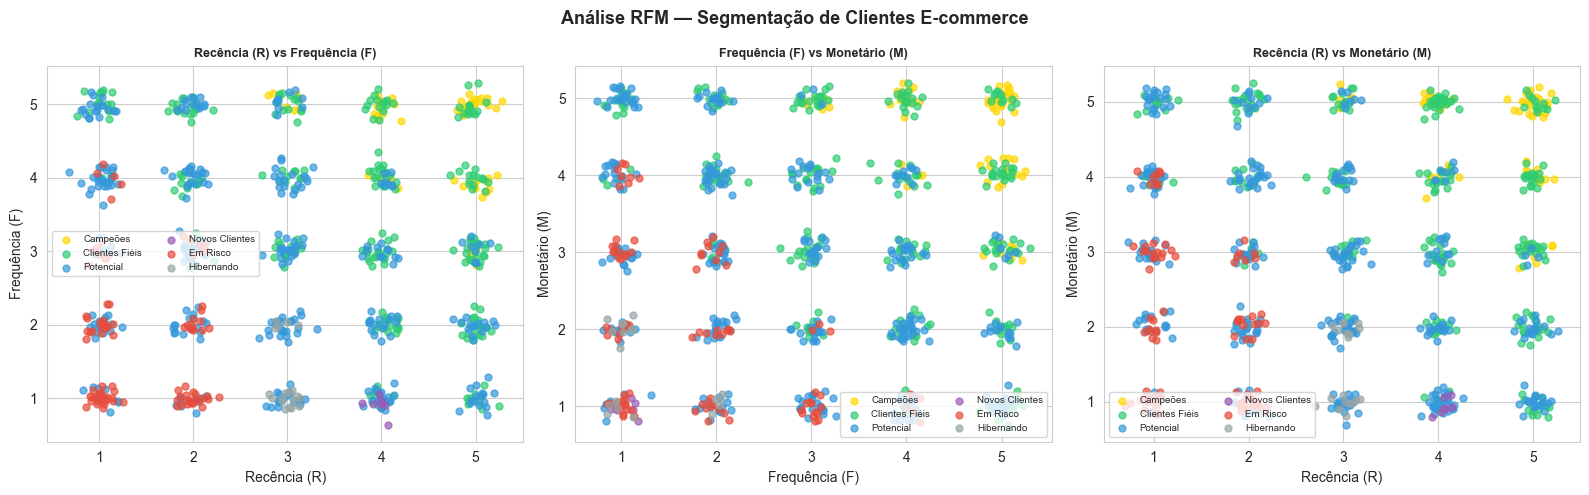

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import boxcox1p
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style("whitegrid")

# ============================================================
# DATASET: Histórico de transações de e-commerce
# ============================================================
n_clientes = 800

# Simular histórico de compras
df_trans = pd.DataFrame({
    'cliente_id': range(1, n_clientes + 1),
    'dias_ultima_compra': np.random.exponential(30, n_clientes).astype(int).clip(1, 365),
    'num_compras_12m': np.random.poisson(4, n_clientes).clip(1, 30),
    'valor_total_12m': np.random.lognormal(6.5, 1.0, n_clientes),
    'ticket_medio': np.random.lognormal(4.5, 0.8, n_clientes),
    'categorias_distintas': np.random.randint(1, 8, n_clientes),
    'segmento': np.random.choice(['Bronze', 'Prata', 'Ouro', 'Diamante'], 
                                  n_clientes, p=[0.45, 0.30, 0.18, 0.07])
})

print("=" * 55)
print("🛒 FEATURES RFM — E-commerce Brasileiro")
print("=" * 55)

# Calcular scores RFM (1-5, onde 5 é o melhor)
df_rfm = df_trans.copy()

# Recência: menor número de dias = melhor (invertido)
df_rfm['R_score'] = pd.qcut(df_rfm['dias_ultima_compra'], q=5, labels=[5,4,3,2,1]).astype(int)

# Frequência: maior número de compras = melhor
df_rfm['F_score'] = pd.qcut(df_rfm['num_compras_12m'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)

# Monetário: maior valor = melhor
df_rfm['M_score'] = pd.qcut(df_rfm['valor_total_12m'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)

# Score RFM combinado
df_rfm['RFM_score'] = df_rfm['R_score'] + df_rfm['F_score'] + df_rfm['M_score']

# Segmentação baseada em RFM
def segmentar_rfm(row):
    if row['RFM_score'] >= 13:
        return 'Campeões'
    elif row['RFM_score'] >= 10:
        return 'Clientes Fiéis'
    elif row['RFM_score'] >= 7:
        return 'Potencial'
    elif row['R_score'] >= 4 and row['F_score'] <= 2:
        return 'Novos Clientes'
    elif row['R_score'] <= 2:
        return 'Em Risco'
    else:
        return 'Hibernando'

df_rfm['segmento_rfm'] = df_rfm.apply(segmentar_rfm, axis=1)

print(f"\nDistribuição de segmentos RFM:")
display(df_rfm['segmento_rfm'].value_counts().to_frame('Clientes'))

# Visualização RFM 3D (projetado em 2D com scatter)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Análise RFM — Segmentação de Clientes E-commerce', fontsize=13, fontweight='bold')

cores_seg = {'Campeões': '#FFD700', 'Clientes Fiéis': '#2ecc71', 'Potencial': '#3498db',
             'Novos Clientes': '#9b59b6', 'Em Risco': '#e74c3c', 'Hibernando': '#95a5a6'}

for ax, (x_col, y_col, x_label, y_label) in zip(axes, [
    ('R_score', 'F_score', 'Recência (R)', 'Frequência (F)'),
    ('F_score', 'M_score', 'Frequência (F)', 'Monetário (M)'),
    ('R_score', 'M_score', 'Recência (R)', 'Monetário (M)'),
]):
    for seg, cor in cores_seg.items():
        mask = df_rfm['segmento_rfm'] == seg
        ax.scatter(df_rfm[mask][x_col] + np.random.randn(mask.sum())*0.1,
                   df_rfm[mask][y_col] + np.random.randn(mask.sum())*0.1,
                   c=cor, label=seg, alpha=0.7, s=25)
    ax.set_xlabel(x_label); ax.set_ylabel(y_label)
    ax.legend(fontsize=7, ncol=2)
    ax.set_title(f'{x_label} vs {y_label}', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('../imagens/03_rfm_segmentacao.png', dpi=150, bbox_inches='tight')
plt.show()

📈 FEATURES DE TENDÊNCIA TEMPORAL

Features criadas: ['vendas', 'lag_1', 'lag_7', 'media_movel_7d', 'media_movel_30d', 'variacao_diaria', 'variacao_pct']

Correlação com vendas:


,vendas
lag_1,0.835
media_movel_7d,0.808
lag_7,0.767
media_movel_30d,0.715
variacao_diaria,0.301
variacao_pct,0.235


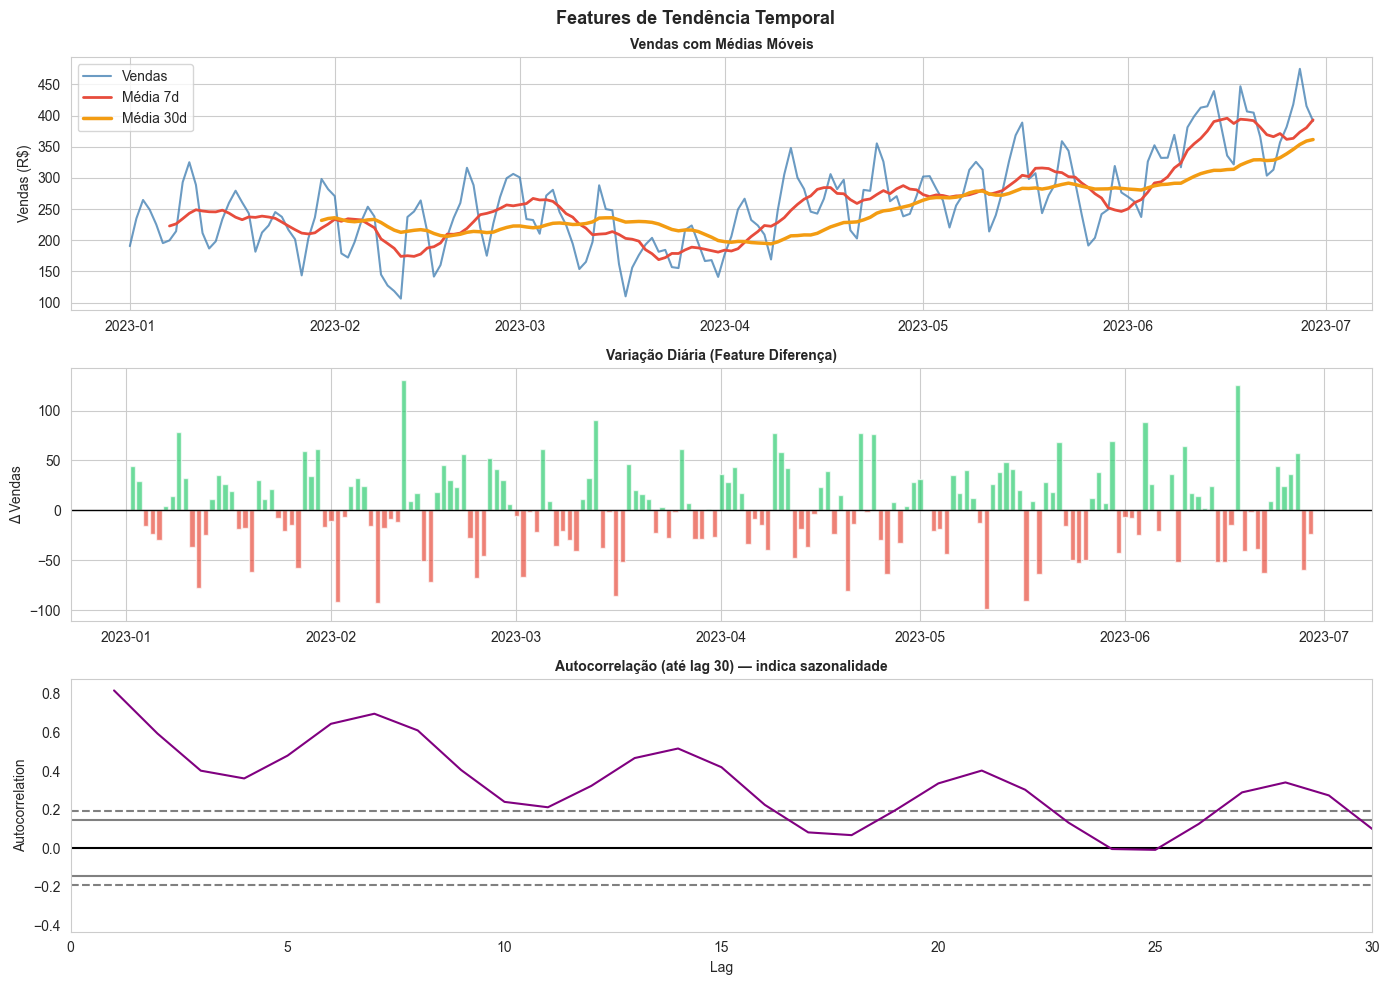

In [2]:
print("=" * 55)
print("📈 FEATURES DE TENDÊNCIA TEMPORAL")
print("=" * 55)

# Simular série temporal de vendas diárias
datas = pd.date_range('2023-01-01', periods=180, freq='D')
vendas = (200 + np.cumsum(np.random.randn(180) * 15) + 
          50 * np.sin(np.arange(180) * 2 * np.pi / 7) +  # sazonalidade semanal
          np.random.randn(180) * 20)
vendas = np.abs(vendas)

df_ts = pd.DataFrame({'data': datas, 'vendas': vendas})
df_ts.set_index('data', inplace=True)

# Criar features de tendência
df_ts['lag_1'] = df_ts['vendas'].shift(1)          # Venda do dia anterior
df_ts['lag_7'] = df_ts['vendas'].shift(7)          # Venda da semana passada
df_ts['media_movel_7d'] = df_ts['vendas'].rolling(7).mean()    # Média 7 dias
df_ts['media_movel_30d'] = df_ts['vendas'].rolling(30).mean()  # Média 30 dias
df_ts['variacao_diaria'] = df_ts['vendas'].diff()              # Diferença dia a dia
df_ts['variacao_pct'] = df_ts['vendas'].pct_change() * 100    # Variação %

df_ts_clean = df_ts.dropna()
print(f"\nFeatures criadas: {list(df_ts.columns)}")
print(f"\nCorrelação com vendas:")
display(df_ts_clean.corr()['vendas'].drop('vendas').sort_values(ascending=False).to_frame().round(3))

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Features de Tendência Temporal', fontsize=13, fontweight='bold')

axes[0].plot(df_ts.index, df_ts['vendas'], color='steelblue', lw=1.5, alpha=0.8, label='Vendas')
axes[0].plot(df_ts.index, df_ts['media_movel_7d'], color='#e74c3c', lw=2, label='Média 7d')
axes[0].plot(df_ts.index, df_ts['media_movel_30d'], color='#f39c12', lw=2.5, label='Média 30d')
axes[0].set_title('Vendas com Médias Móveis', fontweight='bold', fontsize=10)
axes[0].legend(); axes[0].set_ylabel('Vendas (R$)')

axes[1].bar(df_ts.index, df_ts['variacao_diaria'], color=['#2ecc71' if v >= 0 else '#e74c3c' 
             for v in df_ts['variacao_diaria']], alpha=0.7)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Variação Diária (Feature Diferença)', fontweight='bold', fontsize=10)
axes[1].set_ylabel('Δ Vendas')

# Autocorrelação
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(df_ts['vendas'].dropna(), ax=axes[2], color='purple')
axes[2].set_xlim(0, 30)
axes[2].set_title('Autocorrelação (até lag 30) — indica sazonalidade', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../imagens/03_features_temporais.png', dpi=150, bbox_inches='tight')
plt.show()

📐 TRANSFORMAÇÕES PARA NORMALIZAR DISTRIBUIÇÕES


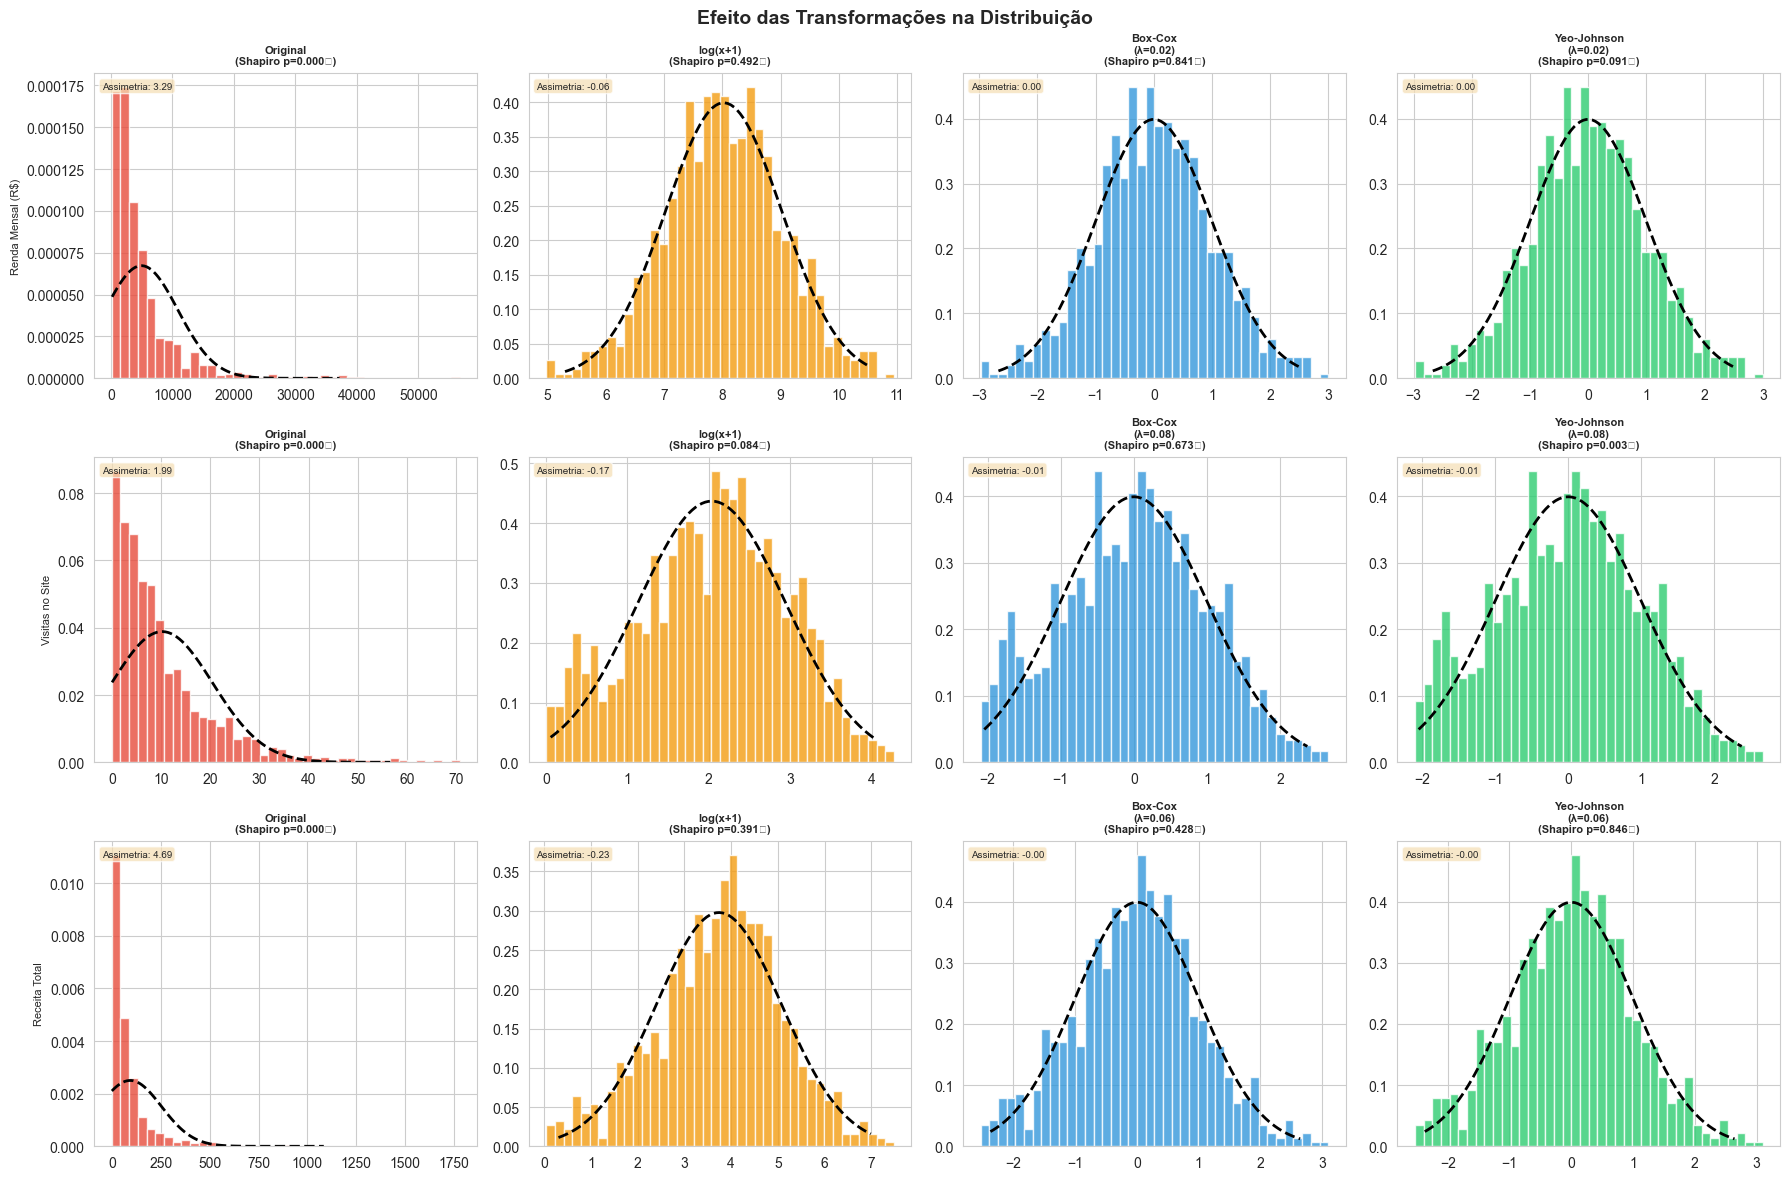


💡 Box-Cox: p > 0.05 (Shapiro-Wilk) indica normalidade!
   Yeo-Johnson funciona mesmo com valores negativos e zeros.


In [3]:
from sklearn.preprocessing import PowerTransformer
from scipy.stats import shapiro, normaltest

print("=" * 55)
print("📐 TRANSFORMAÇÕES PARA NORMALIZAR DISTRIBUIÇÕES")
print("=" * 55)

# Gerar dados assimétricos (típico em ML)
renda = np.random.lognormal(8, 1, 1000)  # renda mensal assimétrica
visitas = np.random.exponential(10, 1000)  # visitas no site
receita_total = np.random.pareto(2, 1000) * 100  # receita (Pareto)

features = {'Renda Mensal (R$)': renda, 
            'Visitas no Site': visitas, 
            'Receita Total': receita_total}

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Efeito das Transformações na Distribuição', fontsize=14, fontweight='bold')

for row, (nome, dados) in enumerate(features.items()):
    dados_pos = dados + 1  # garantir positivo para Box-Cox
    
    # Aplicar transformações
    pt_boxcox = PowerTransformer(method='box-cox')
    pt_yeojohn = PowerTransformer(method='yeo-johnson')
    
    dados_log = np.log1p(dados)
    dados_bc = pt_boxcox.fit_transform(dados_pos.reshape(-1,1)).flatten()
    dados_yj = pt_yeojohn.fit_transform(dados.reshape(-1,1)).flatten()
    
    transformacoes = [
        (dados, 'Original', '#e74c3c'),
        (dados_log, f'log(x+1)', '#f39c12'),
        (dados_bc, f'Box-Cox\n(λ={pt_boxcox.lambdas_[0]:.2f})', '#3498db'),
        (dados_yj, f'Yeo-Johnson\n(λ={pt_yeojohn.lambdas_[0]:.2f})', '#2ecc71'),
    ]
    
    for col, (transf, titulo, cor) in enumerate(transformacoes):
        ax = axes[row, col]
        ax.hist(transf, bins=40, color=cor, edgecolor='white', alpha=0.8, density=True)
        
        # Teste de normalidade (Shapiro-Wilk em amostra de 200)
        amostra = np.random.choice(transf, min(200, len(transf)), replace=False)
        _, p_valor = shapiro(amostra)
        
        # Sobrepor curva normal
        mu, sigma = np.mean(transf), np.std(transf)
        x_range = np.linspace(np.percentile(transf, 0.5), np.percentile(transf, 99.5), 100)
        ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma), 'black', lw=2, linestyle='--')
        
        ax.set_title(f'{titulo}\n(Shapiro p={p_valor:.3f}{"✅" if p_valor > 0.05 else "❌"})', 
                     fontsize=8, fontweight='bold')
        if col == 0:
            ax.set_ylabel(nome, fontsize=8)
        
        # Calcular assimetria
        assimetria = stats.skew(transf)
        ax.text(0.02, 0.97, f'Assimetria: {assimetria:.2f}', transform=ax.transAxes,
                fontsize=7, va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig('../imagens/03_transformacoes.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Box-Cox: p > 0.05 (Shapiro-Wilk) indica normalidade!")
print("   Yeo-Johnson funciona mesmo com valores negativos e zeros.")

🔍 PCA — ANÁLISE DE COMPONENTES PRINCIPAIS


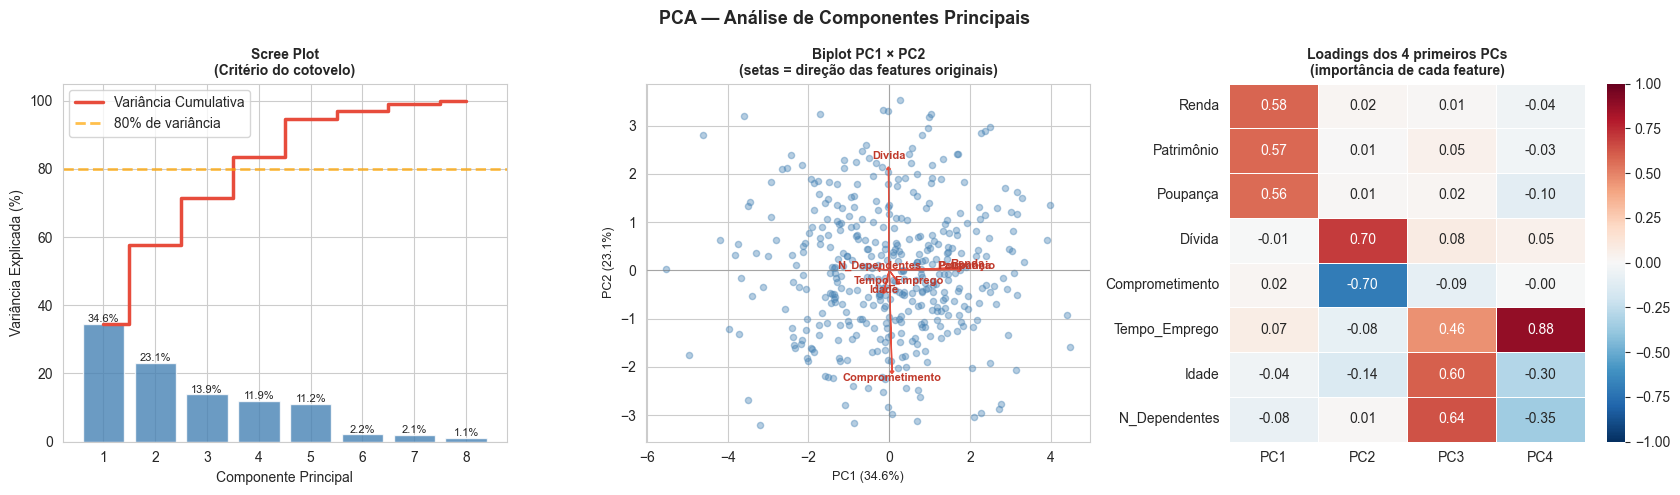


📊 4 componentes explicam ≥ 80% da variância (de 8 originais)
   Redução: 8 → 4 dimensões (50% de compressão)


In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("=" * 55)
print("🔍 PCA — ANÁLISE DE COMPONENTES PRINCIPAIS")
print("=" * 55)

# Dataset sintético multi-dimensional
n_samples = 400
X_raw = np.random.randn(n_samples, 8)
# Criar correlações artificiais
X_raw[:, 1] = X_raw[:, 0] * 0.8 + np.random.randn(n_samples) * 0.4
X_raw[:, 2] = X_raw[:, 0] * 0.6 + X_raw[:, 1] * 0.3 + np.random.randn(n_samples) * 0.5
X_raw[:, 4] = -X_raw[:, 3] * 0.7 + np.random.randn(n_samples) * 0.5

feature_names = ['Renda', 'Patrimônio', 'Poupança', 'Dívida', 
                 'Comprometimento', 'Tempo_Emprego', 'Idade', 'N_Dependentes']

# Padronizar antes do PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Aplicar PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

var_explicada = pca.explained_variance_ratio_
var_cumulativa = np.cumsum(var_explicada)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('PCA — Análise de Componentes Principais', fontsize=13, fontweight='bold')

# Scree Plot
bars = axes[0].bar(range(1, 9), var_explicada * 100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].step(range(1, 9), var_cumulativa * 100, where='mid', color='#e74c3c', lw=2.5, 
             label='Variância Cumulativa')
axes[0].axhline(80, color='orange', lw=2, linestyle='--', alpha=0.7, label='80% de variância')
axes[0].set_xlabel('Componente Principal'); axes[0].set_ylabel('Variância Explicada (%)')
axes[0].set_title('Scree Plot\n(Critério do cotovelo)', fontweight='bold', fontsize=10)
axes[0].legend()
for bar, v in zip(bars, var_explicada*100):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v:.1f}%', ha='center', fontsize=8)

# Biplot (PC1 vs PC2)
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4, s=20, color='steelblue')
# Vetores dos loadings
scale = 3
for i, (nome, loading) in enumerate(zip(feature_names, pca.components_[:2].T)):
    axes[1].arrow(0, 0, loading[0]*scale, loading[1]*scale,
                  head_width=0.1, head_length=0.05, fc='#e74c3c', ec='#e74c3c')
    axes[1].text(loading[0]*scale*1.1, loading[1]*scale*1.1, nome, 
                 fontsize=8, ha='center', color='#c0392b', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({var_explicada[0]*100:.1f}%)', fontsize=9)
axes[1].set_ylabel(f'PC2 ({var_explicada[1]*100:.1f}%)', fontsize=9)
axes[1].set_title('Biplot PC1 × PC2\n(setas = direção das features originais)', fontweight='bold', fontsize=10)
axes[1].axhline(0, color='gray', lw=0.8, linestyle='-', alpha=0.5)
axes[1].axvline(0, color='gray', lw=0.8, linestyle='-', alpha=0.5)

# Heatmap dos loadings
loadings_df = pd.DataFrame(pca.components_[:4].T, 
                            index=feature_names,
                            columns=[f'PC{i}' for i in range(1, 5)])
sns.heatmap(loadings_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[2], linewidths=0.5, vmin=-1, vmax=1)
axes[2].set_title('Loadings dos 4 primeiros PCs\n(importância de cada feature)', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../imagens/03_pca.png', dpi=150, bbox_inches='tight')
plt.show()

n_componentes_80 = (var_cumulativa < 0.80).sum() + 1
print(f"\n📊 {n_componentes_80} componentes explicam ≥ 80% da variância (de 8 originais)")
print(f"   Redução: {8} → {n_componentes_80} dimensões ({(1 - n_componentes_80/8)*100:.0f}% de compressão)")

🌐 t-SNE — VISUALIZAÇÃO DE ALTA DIMENSÃO
Shape original: (400, 20) (20 dimensões)


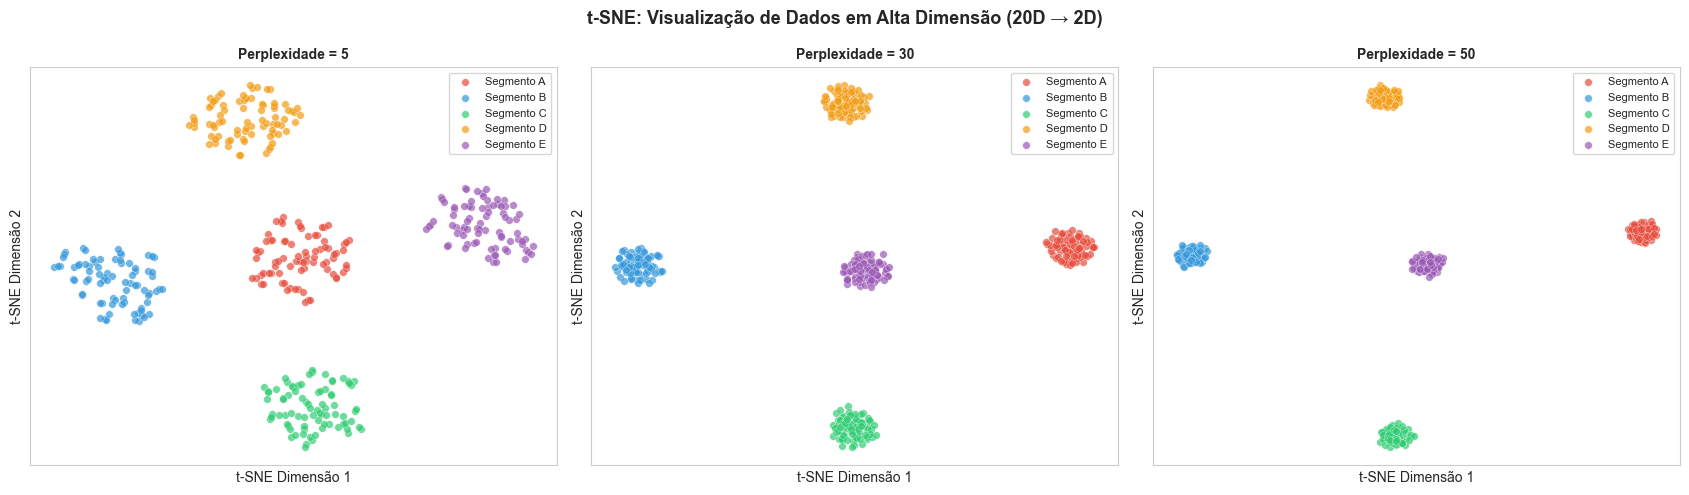


💡 Dica: Perplexidade entre 20-50 geralmente funciona melhor.
   t-SNE é para VISUALIZAÇÃO, não para usar como features no modelo!
   Para features, use PCA ou UMAP.


In [5]:
from sklearn.manifold import TSNE
from sklearn.datasets import make_blobs

print("=" * 55)
print("🌐 t-SNE — VISUALIZAÇÃO DE ALTA DIMENSÃO")
print("=" * 55)

# Dataset de alta dimensão com clusters
X_high, y_high = make_blobs(n_samples=400, centers=5, n_features=20, 
                              cluster_std=2.0, random_state=42)
nomes_clusters = ['Segmento A', 'Segmento B', 'Segmento C', 'Segmento D', 'Segmento E']

print(f"Shape original: {X_high.shape} (20 dimensões)")

# Aplicar t-SNE com diferentes perplexidades
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('t-SNE: Visualização de Dados em Alta Dimensão (20D → 2D)', 
             fontsize=13, fontweight='bold')

palette = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for ax, perplexidade in zip(axes, [5, 30, 50]):
    tsne = TSNE(n_components=2, perplexity=perplexidade, max_iter=1000, random_state=42)
    X_tsne = tsne.fit_transform(X_high)
    
    for cluster_id, (nome, cor) in enumerate(zip(nomes_clusters, palette)):
        mask = y_high == cluster_id
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=cor, label=nome, 
                   alpha=0.7, s=30, edgecolors='white', linewidths=0.3)
    
    ax.set_title(f'Perplexidade = {perplexidade}', fontweight='bold', fontsize=10)
    ax.set_xlabel('t-SNE Dimensão 1'); ax.set_ylabel('t-SNE Dimensão 2')
    ax.legend(fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig('../imagens/03_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Dica: Perplexidade entre 20-50 geralmente funciona melhor.")
print("   t-SNE é para VISUALIZAÇÃO, não para usar como features no modelo!")
print("   Para features, use PCA ou UMAP.")

## 6. Resumo e Pontos-Chave

| Técnica | Problema Resolvido | Quando Usar |
|---------|-------------------|-------------|
| RFM | Segmentação de clientes | E-commerce, CRM, marketing |
| Lag / Rolling Mean | Capturar tendência temporal | Séries temporais |
| log(x+1) | Assimetria positiva severa | Rendas, preços, contagens |
| Box-Cox | Assimetria + otimizar λ | Dados estritamente positivos |
| Yeo-Johnson | Assimetria + aceita negativos | Dados gerais |
| PCA | Reduzir dimensionalidade | Muitas features correlacionadas |
| t-SNE | Visualizar clusters | Exploração/diagnóstico apenas |

### ⚠️ Armadilhas
1. **t-SNE não é reproduzível sem random_state** e muda muito com perplexidade
2. **PCA deve ser ajustado no treino** e aplicado no teste (evitar data leakage)
3. **Box-Cox exige valores > 0** — adicione 1 se necessário (ou use Yeo-Johnson)
4. **RFM precisa de definição de data de referência** — use a data mais recente do dataset

## 7. Exercícios Propostos

1. **RFM**: Para o dataset do módulo, crie um 4º indicador: "P (Produto)" — diversidade de categorias compradas. Quais clientes são mais diversificados?

2. **Transformações**: Gere dados com distribuição Poisson(λ=3) e compare Log, Box-Cox e Yeo-Johnson. Qual normaliza melhor?

3. **PCA**: No dataset do módulo, quantos componentes são necessários para explicar 90% da variância? Use um gráfico de scree plot.

4. **t-SNE**: Aplique t-SNE no dataset MNIST (sklearn.datasets.load_digits) e veja se os dígitos ficam separados em clusters.